##### Conditional generation of DCGAN with Animals Dataset

In [1]:
import os
import torch
import random
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.optim import Adam
from torch.utils.data import DataLoader
import torchvision.utils as vutils
from torchvision.utils import save_image

In [2]:
path = os.path.join(os.getcwd(), 'data','conditional_animals')
workers = 8
batch_size = 1
image_size = 128
nc = 3
latent_dim = 100
gen_feature = 128
dis_feature = 256
num_epochs = 100
lr = 1e-5
beta1 = 0.5
ngpu = 1
gen_embedding = latent_dim
num_classes = 20
device = torch.device("cuda" if (torch.cuda.is_available() and ngpu > 0) else "cpu")
print(device)


cuda


In [3]:
# We can use an image folder dataset the way we have it setup.
# Create the dataset
mean = torch.tensor([0.50869316, 0.50057036, 0.44047505])
std = torch.tensor([0.20191325, 0.19737212, 0.20100889])
dataset = datasets.ImageFolder(root=path,
                           transform=transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.CenterCrop(image_size),
                               transforms.ToTensor(),
                               transforms.Normalize(mean,std),
                           ]))
# Create the dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)

# choose 20 random classes and show one image from each class with label
# Extract unique classes
classes = dataset.classes
# Randomly select 20 classes
selected_classes = random.sample(classes, 20)
# Create mapping dictionary
label_mapping = {original: new for new, original in enumerate(selected_classes)}
print(f"Label mapping: {label_mapping}")

Label mapping: {'beetle': 0, 'bear': 1, 'dog': 2, 'cat': 3, 'chimpanzee': 4, 'cow': 5, 'coyote': 6, 'antelope': 7, 'crow': 8, 'crab': 9, 'bee': 10, 'deer': 11, 'dolphin': 12, 'cockroach': 13, 'butterfly': 14, 'badger': 15, 'boar': 16, 'bat': 17, 'bison': 18, 'caterpillar': 19}


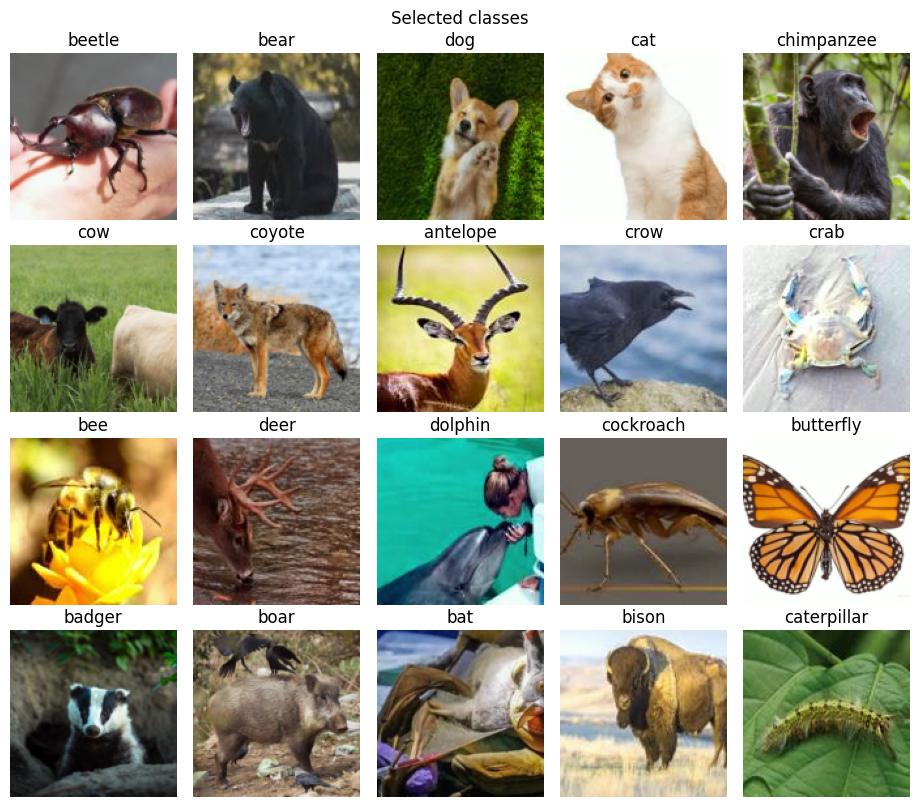

In [4]:
# Custom dataset class
class CustomImageFolder(datasets.ImageFolder):
    def __init__(self, root, transform, label_mapping):
        super().__init__(root, transform)
        self.label_mapping = label_mapping

    def __getitem__(self, index):
        path, target = self.samples[index]
        sample = self.loader(path)
        if self.transform is not None:
            sample = self.transform(sample)
        if self.target_transform is not None:
            target = self.target_transform(target)
        # Apply label mapping
        target = self.label_mapping[self.classes[target]]
        return sample, target
# Create the custom dataset
custom_dataset = CustomImageFolder(root=path,
                                   transform=transforms.Compose([
                                       transforms.Resize(image_size),
                                       transforms.CenterCrop(image_size),
                                       transforms.ToTensor(),
                                       transforms.Normalize(mean, std),
                                   ]),
                                   label_mapping=label_mapping)

# # Create the dataloader
dataloader = torch.utils.data.DataLoader(custom_dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)
# Create a dictionary to store one image per selected class
images_per_class = {cls: None for cls in selected_classes}

# Iterate through the dataset to find one image per selected class
for images, labels in dataloader:
    for img, label in zip(images, labels):
        label_name = classes[label.item()]
        if label_name in selected_classes and images_per_class[label_name] is None:
            images_per_class[label_name] = (img.permute(1, 2, 0).numpy(), label_name)
        if all(images_per_class.values()):
            break
    if all(images_per_class.values()):
        break
# Plot the images with their labels

plt.figure(figsize=(10,8))
plt.suptitle("Selected classes",y=1)

plt.axis('off')
for i, (image, label) in enumerate(images_per_class.values()):
    plt.subplot(4, 5, i + 1)
    image = torch.tensor(image)
    plt.imshow(image*std[1,None,None] + mean)  # Unnormalize the image
    plt.title(label)
    plt.axis('off')
plt.subplots_adjust(wspace=0.1, hspace=0.1, top=0.95, bottom=0.01, left=0.05, right=0.95)
plt.show()

In [5]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [6]:
class Generator(nn.Module):
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.num_classes = num_classes  
        self.latent_dim = latent_dim
        self.gen_feature = gen_feature
        self.gen_embedding = gen_embedding
        self.image_size = image_size
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            self.generator_block(latent_dim + gen_embedding, gen_feature * 16 , 4, 1, 0),
            # state size. (gen_feature*8) x 4 x 4
            self.generator_block(gen_feature * 16 , gen_feature * 8, 4, 2, 1),
            # state size. (gen_feature*4) x 8 x 8
            self.generator_block(gen_feature * 8, gen_feature  * 4, 4, 2, 1),
            # state size. (gen_feature*2) x 16 x 16
            self.generator_block(gen_feature * 4, gen_feature * 2, 4, 2, 1),
            # state size. (gen_feature) x 32 x 32
            self.generator_block(gen_feature*2 , gen_feature, 4, 2, 1),
            # state size. (gen_feature) x 64 x 64
            nn.ConvTranspose2d(gen_feature , nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # state size. (nc) x 128 x 128
        )
        self.embedding = nn.Embedding(num_classes, gen_embedding)


    def generator_block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(True)
        )

    def forward(self, input,labels):
        # Concatenate label embedding and noise to produce input
        label_embedding = self.embedding(labels)
        x = torch.cat([input, label_embedding], 1)
        x = x.view(input.size(0),-1, 1, 1)
        return self.main(x)
    
# Create the generator
netG = Generator(ngpu).to(device)
netG.apply(weights_init)


class Discriminator(nn.Module):
    def __init__(self, ngpu):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.image_size = image_size
        self.num_classes = num_classes
        self.main = nn.Sequential(
            # input is (nc) x 128 x 128
            nn.Conv2d(nc + 1 , dis_feature, 4, 2, 1, bias=False),
            # input is (nc) x 64 x 64
            self.discriminator_block(dis_feature, dis_feature*2, 4, 2, 1),
            # state size. (dis_feature) x 32 x 32
            self.discriminator_block(dis_feature*2, dis_feature * 4, 4, 2, 1),
            # state size. (dis_feature*2) x 16 x 16
            self.discriminator_block(dis_feature * 4, dis_feature * 8, 4, 2, 1),
            # state size. (dis_feature*4) x 8 x 8
            self.discriminator_block(dis_feature * 8, dis_feature * 16, 4, 2, 1),
            # state size. (dis_feature*8) x 4 x 4
            nn.Conv2d(dis_feature * 16, 1, 4, 1, 0, bias=False),
            # nn.Sigmoid()
        )
        self.embed = nn.Embedding(num_classes, image_size * image_size)

    def discriminator_block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True)
        )
    def forward(self, input, labels):
        input = input + torch.randn(input.size()).to(device) * 0.005
        label_embedding = self.embed(labels)
        label_embedding = label_embedding.view(input.size(0), 1, input.size(2), input.size(3))
        x = torch.cat([input, label_embedding], 1)
        return self.main(x)
    

# Create the Discriminator
netD = Discriminator(ngpu).to(device)
netD.apply(weights_init)
# Initialize the ``BCELoss`` function
criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
#  the progression of the generator
fixed_noise = torch.randn(batch_size, latent_dim, device=device)


# Setup Adam optimizers for both G and D
optimizerD = Adam(netD.parameters(), lr=lr, betas=(beta1, 0.9))
optimizerG = Adam(netG.parameters(), lr=lr, betas=(beta1, 0.9))


In [ ]:
# Training Loop
# Lists to keep track of progress
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
img_list = []
G_losses = []
D_losses = []
iters = 0
n_critic = 5

print("Starting Training Loop...")
for epoch in range(num_epochs):
    for image,labels in dataloader:
        image = image.to(device)
        labels=labels.to(device)
        print(f"Image device: {image.device}, Labels device: {labels.device}")
        print(f"Image shape: {image.shape}, Labels shape: {labels.shape}")        
        for _ in range(n_critic):
            netD.zero_grad()
            #Train with real image
            real_output = netD(image, labels)
            errD_real = criterion(real_output, torch.full_like(real_output,0.9))
            #Train with fake images generated by generator
            sample = torch.randn(image.size(0), latent_dim, device=device)
            fake = netG(sample, labels)
            fake_output = netD(fake.detach(), labels)
            errD_fake = criterion(fake_output, torch.zeros_like(fake_output))
            #Total Loss 
            errD = errD_real + errD_fake
            errD.backward()
            optimizerD.step()
        netG.zero_grad()
        #Train generator
        fake = netG(sample, labels)
        output = netD(fake, labels)
        errG = criterion(output, torch.ones_like(output))
        errG.backward()
        optimizerG.step()
        # Output training stats
        if iters % 50 == 0:
            print(f"Epoch [{epoch}/{num_epochs}] Loss D: {errD.item()} Loss G: {errG.item()}")
            G_losses.append(errG.item())
            D_losses.append(errD.item())
        # Save Losses for plotting later
        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(fixed_noise, labels).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

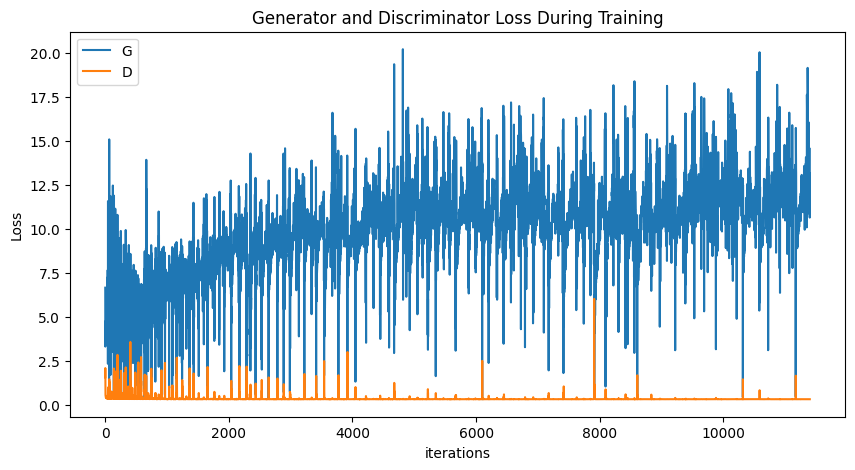

In [13]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

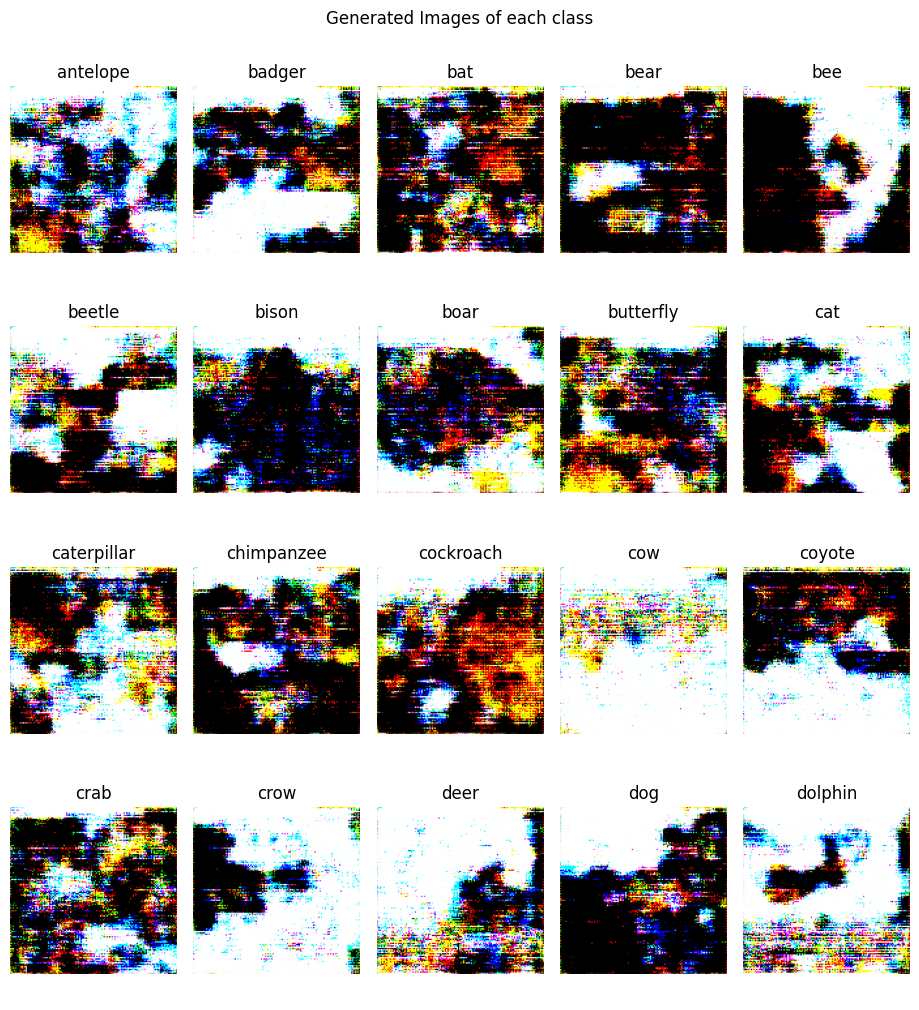

In [14]:
import torch
import matplotlib.pyplot as plt

# Load the model
model = torch.load('c-dcgan_generator.pth', weights_only=False)
model.eval()

# Generate some fake images
plt.figure(figsize=(10, 10))
plt.axis("off")
plt.suptitle("Generated Images of each class", y=1)
for i in range(20):
    fixed_noise = torch.randn(1, latent_dim, 1, 1, device=device)  # Different noise for each image
    label = torch.tensor([i], device=device)  # Create a tensor for the label
    fake = model(fixed_noise, label).detach().cpu()  # Assuming model takes noise and class label
    fake_image = fake.squeeze(0)  # Remove the batch dimension
    
    # Rescale from [-1, 1] to [0, 1]
    fake_image = (fake_image + 1) / 2.0
    
    plt.subplot(4, 5, i + 1)
    plt.axis("off")
    plt.imshow(fake_image.permute(1, 2, 0))  # Correct usage of plt.imshow
    plt.title(classes[i])

plt.subplots_adjust(wspace=0.1, hspace=0.1, top=0.95, bottom=0.01, left=0.05, right=0.95)
plt.show()


FID Calculation

In [ ]:
import numpy as np
fake_images = []

for i in range(1000):
    noise = torch.randn(1, latent_dim, 1, 1).to(device)
    img = model(noise).detach().cpu().numpy().squeeze()
    # 0 to 1 normalization
    img = (img - img.min()) / (img.max() - img.min())
    fake_images.append(img)
fake_images = np.array(fake_images)
# 1000 real fake_images in tensor format
real_images = []
# sample 1000 images from the training set
for i in range(1000):
    img = dataset[i][0].numpy().squeeze()
    # 0 to 1 normalization
    img = (img - img.min()) / (img.max() - img.min())
    real_images.append(img)


import torch
from torcheval.metrics import FrechetInceptionDistance



# Initialize FID metric calculator
fid_metric = FrechetInceptionDistance(feature_dim=2048)  # FID is typically computed using Inception-V3 features with 2048 dimensions
# normalize the images

# Update the FID metric with real and fake images
fid_metric.update(torch.tensor(real_images), is_real=True)
fid_metric.update(torch.tensor(fake_images), is_real=False)

# Compute the FID score
fid_score = fid_metric.compute()

print(f"FID Score: {fid_score.item()}")

FID Score: 163.83697509765625


#### Q6 Learnings:

It took our maximum time but images are still noisy due to some weird reasons which we don't know. Whole architecture and framework is correct as per our understanding. \ 

Images are very noisy but still FID came 163 which is surprising becuase, in WGAN code visually better images gave worse FID.